In [1]:
import os
import torch

from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from yacs.config import CfgNode as CN

from data.dataset import make_dataset
from eval import evaluate
from src.model import Model
from src.utils import clean_exp_savedir
from src.losses import supervised_loss
import argparse

In [2]:
source_train_loader, _, source_test_loader, target_test_loader = (
    make_dataset(
        source_dataset="office31_amazon",
        target_dataset="office31_dslr",
        img_size=384,
        train_bs=16,
        eval_bs=64,
        num_workers=16,
    )
)

In [3]:
model = Model(
    backbone_type="vit_b_32",
    in_dim=768,
    hidden_dim=256,
        out_dim=31,
    imgsize=384,
    attribute_layers=6,
    patch_size=32,
    attr_net_type="transformer",
)
device = torch.device("cuda")
model = model.to(device)
ckpt = torch.load("exp/exp_1/bi_best_100.00.pth", weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])

Loaded pretrained weights.


<All keys matched successfully>

In [4]:
class GradCam:
    def __init__(self, model, target):
        self.model = model.eval()
        self.feature = None
        self.gradient = None
        self.target = target
        self._get_hook()

    def _get_features_hook(self, module, input, output):
        self.feature = self.reshape_transform(output)

    def _get_grads_hook(self, module, input, output):
        if not output.requires_grad:
            return
            
        def _store_grad(grad):
            self.gradient = self.reshape_transform(grad)
        output.register_hook(_store_grad)
    def _get_hook(self):
        self.target.register_forward_hook(self._get_features_hook)
        self.target.register_forward_hook(self._get_grads_hook)

    def reshape_transform(self, tensor):
        result = tensor[:, 1:, :]
        B, num_patches, C = result.shape
        H = W = int(num_patches ** 0.5)
        if H * W != num_patches:
            raise ValueError(f"Non-square patch grid: {num_patches} patches")
        return result.reshape(B, H, W, C).permute(0, 3, 1, 2) 

    def __call__(self, inputs):
        # 1. Force the input to require gradients so autograd builds the graph
        inputs = inputs.clone().requires_grad_(True)
        
        self.model.zero_grad()
        output = self.model(inputs, branch="src")
        index = np.argmax(output.cpu().data.numpy(), axis=1)    # [B] - per image

        # Backward on the top class score summed over batch
        target = output[range(len(index)), index].sum()
        target.backward()

        # Generate CAM per image in the batch
        cams = []
        for i in range(inputs.shape[0]):
            gradient = self.gradient[i].cpu().data.numpy()      # [C, H, W]
            weight = np.mean(gradient, axis=(1, 2))             # [C]
            feature = self.feature[i].cpu().data.numpy()        # [C, H, W]
            cam = np.sum(feature * weight[:, np.newaxis, np.newaxis], axis=0)
            cam = np.maximum(cam, 0)
            cam = cam - np.min(cam)
            cam = cam / (np.max(cam) + 1e-8)
            cam = cv2.resize(cam, (inputs.shape[-1], inputs.shape[-2]))
            cams.append(cam)
        return np.stack(cams, axis=0)                           # [B, H, W]# [B, H, W]

In [5]:
def prepare_input(image):
    image = image.copy() 

    # Normalize the image using the mean and standard deviation
    means = np.array([0.5, 0.5, 0.5])
    stds = np.array([0.5, 0.5, 0.5])
    image -= means
    image /= stds

    # Transpose the image to match the model's expected input format (C, H, W)
    image = np.ascontiguousarray(np.transpose(image, (2, 0, 1)))
    image = image[np.newaxis, ...]  # Add batch dimension

    return torch.tensor(image, requires_grad=True)

def gen_cam(image, mask):
    # Create a heatmap from the Grad-CAM mask
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    # Superimpose the heatmap on the original image
    cam = (1 - 0.5) * heatmap + 0.5 * image
    cam = cam / np.max(cam)  # Normalize the result
    return np.uint8(255 * cam)  # Convert to 8-bit image
def visualize_grad_cam_vit(model, image):
    target_layer = model.backbone.transformer.blocks[-1].norm1
    grad_cam = GradCam(model, target_layer)
    mask = grad_cam(image)
    results = gen_cam(image, mask)
    return results

In [8]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cv2
from torchvision.utils import make_grid


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor: torch.Tensor) -> torch.Tensor:
    """Reverse ImageNet normalization for display. tensor: [C, H, W]"""
    mean = IMAGENET_MEAN.to(tensor.device).view(3, 1, 1)
    std  = IMAGENET_STD.to(tensor.device).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def evaluate_and_visualize_failures(
    model,
    branch: str,
    test_loader,
    device: torch.device,
    num_classes: int,
    class_names: list[str] | None = None,
    max_samples_per_class: int = 4,
    save_path: str = "failure_visualization.png",
):
    model.eval()
    criterion = torch.nn.CrossEntropyLoss()
    correct_per_class = torch.zeros(num_classes, device=device)
    total_per_class   = torch.zeros(num_classes, device=device)
    total_loss, total, correct = 0.0, 0, 0

    failing_samples: dict[int, list[tuple]] = {c: [] for c in range(num_classes)}
    grad_cam = GradCam(model, model.backbone.transformer.blocks[-1].norm1)
    samples_needed = {c: max_samples_per_class for c in range(num_classes)}

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # ── Accuracy tracking under no_grad ─────────────────────────────
        with torch.no_grad():
            pred = model(images, branch=branch)
            loss = criterion(pred, labels)
            _, predicted = torch.max(pred, 1)

            total_loss += loss.item() * images.size(0)
            total      += labels.size(0)
            correct    += (predicted == labels).sum().item()

            for c in range(num_classes):
                class_mask = (labels == c)
                total_per_class[c]   += class_mask.sum()
                correct_per_class[c] += (predicted[class_mask] == labels[class_mask]).sum()

            wrong_idx = (predicted != labels).nonzero(as_tuple=True)[0]

        if len(wrong_idx) == 0:
            continue

        # ── GradCAM one image at a time, skip classes already full ──────
        for global_idx in wrong_idx:
            c = labels[global_idx].item()

            if samples_needed[c] <= 0:
                continue

            # Single image — minimal memory footprint
            single_img = images[global_idx].unsqueeze(0)   # [1, 3, H, W]
            model.zero_grad()
            cam = grad_cam(single_img)                      # [1, H, W]

            cam_rgb = cv2.applyColorMap(
                np.uint8(255 * cam[0]), cv2.COLORMAP_JET
            )
            cam_rgb = cv2.cvtColor(cam_rgb, cv2.COLOR_BGR2RGB)
            cam_tensor = torch.from_numpy(
                cam_rgb.transpose(2, 0, 1)
            ).float() / 255.0                              # [3, H, W] on CPU

            failing_samples[c].append((
                images[global_idx].detach().cpu(),
                cam_tensor,
                predicted[global_idx].item(),
            ))
            samples_needed[c] -= 1
            model.zero_grad()

        del images, labels, pred, predicted
        torch.cuda.empty_cache()

    # ── Identify 10 lowest accuracy classes that have samples ────────────
    class_wise_accuracy = torch.where(
        total_per_class > 0,
        (correct_per_class / total_per_class) * 100,
        torch.tensor(0.0, device=device),
    )
    struggling_classes = sorted(
        [c for c in range(num_classes) if total_per_class[c].item() > 0],
        key=lambda c: class_wise_accuracy[c].item()
    )[:10]

    avg_loss = total_loss / total
    accuracy = 100 * correct / total

    print(f"Overall — Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    for c in struggling_classes:
        label = class_names[c] if class_names else f"Class {c}"
        print(f"  [{c}] {label}: {class_wise_accuracy[c].item():.1f}%  "
              f"({int(correct_per_class[c])}/{int(total_per_class[c])} correct)")

    if not struggling_classes:
        print("No struggling classes found — nothing to visualize.")
        return avg_loss, accuracy, class_wise_accuracy

    # ── Build figure ─────────────────────────────────────────────────────
    n_cols = max_samples_per_class * 2
    n_rows = len(struggling_classes)

    fig = plt.figure(figsize=(n_cols * 2.5, n_rows * 3.2))
    fig.suptitle(
        f"10 Lowest Accuracy Classes",
        fontsize=14, fontweight="bold", y=1.01,
    )
    outer = gridspec.GridSpec(n_rows, 1, figure=fig, hspace=0.55)

    for row_idx, c in enumerate(struggling_classes):
        class_label = class_names[c] if class_names else f"Class {c}"
        samples     = failing_samples[c]

        inner = gridspec.GridSpecFromSubplotSpec(
            2, max_samples_per_class,
            subplot_spec=outer[row_idx],
            wspace=0.05, hspace=0.15,
        )

        header_ax = fig.add_subplot(outer[row_idx])
        header_ax.set_title(
            f"{class_label}  |  acc={class_wise_accuracy[c].item():.1f}%  |  "
            f"{int(total_per_class[c].item())} samples",
            fontsize=10, fontweight="bold", loc="left", pad=12, color="crimson",
        )
        header_ax.axis("off")

        for col_idx in range(max_samples_per_class):
            ax_orig = fig.add_subplot(inner[0, col_idx])
            ax_mask = fig.add_subplot(inner[1, col_idx])

            if col_idx < len(samples):
                orig, cam_tensor, pred_idx = samples[col_idx]
                pred_label = class_names[pred_idx] if class_names else f"cls {pred_idx}"

                ax_orig.imshow(denormalize(orig).permute(1, 2, 0).numpy())
                ax_orig.set_title("orig", fontsize=7, pad=2)

                ax_mask.imshow(cam_tensor.permute(1, 2, 0).numpy())
                ax_mask.set_title(f"pred: {pred_label}", fontsize=7, pad=2, color="firebrick")
            else:
                ax_orig.text(0.5, 0.5, "—", ha="center", va="center", fontsize=12, color="grey")
                ax_mask.text(0.5, 0.5, "—", ha="center", va="center", fontsize=12, color="grey")

            for ax in (ax_orig, ax_mask):
                ax.axis("off")

        label_ax = fig.add_subplot(inner[:, 0])
        label_ax.set_ylabel("orig\n\ncam", fontsize=8, rotation=0,
                            labelpad=40, va="center", color="dimgrey")
        label_ax.axis("off")

    plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

    return avg_loss, accuracy, class_wise_accuracy

Overall — Loss: 0.6354 | Accuracy: 85.17%
  [3] Class 3: 41.7%  (5/12 correct)
  [27] Class 27: 48.1%  (13/27 correct)
  [28] Class 28: 57.1%  (12/21 correct)
  [24] Class 24: 60.0%  (6/10 correct)
  [14] Class 14: 67.7%  (21/31 correct)
  [8] Class 8: 73.3%  (11/15 correct)
  [15] Class 15: 77.3%  (17/22 correct)
  [23] Class 23: 77.8%  (14/18 correct)
  [9] Class 9: 80.0%  (12/15 correct)
  [11] Class 11: 80.0%  (8/10 correct)


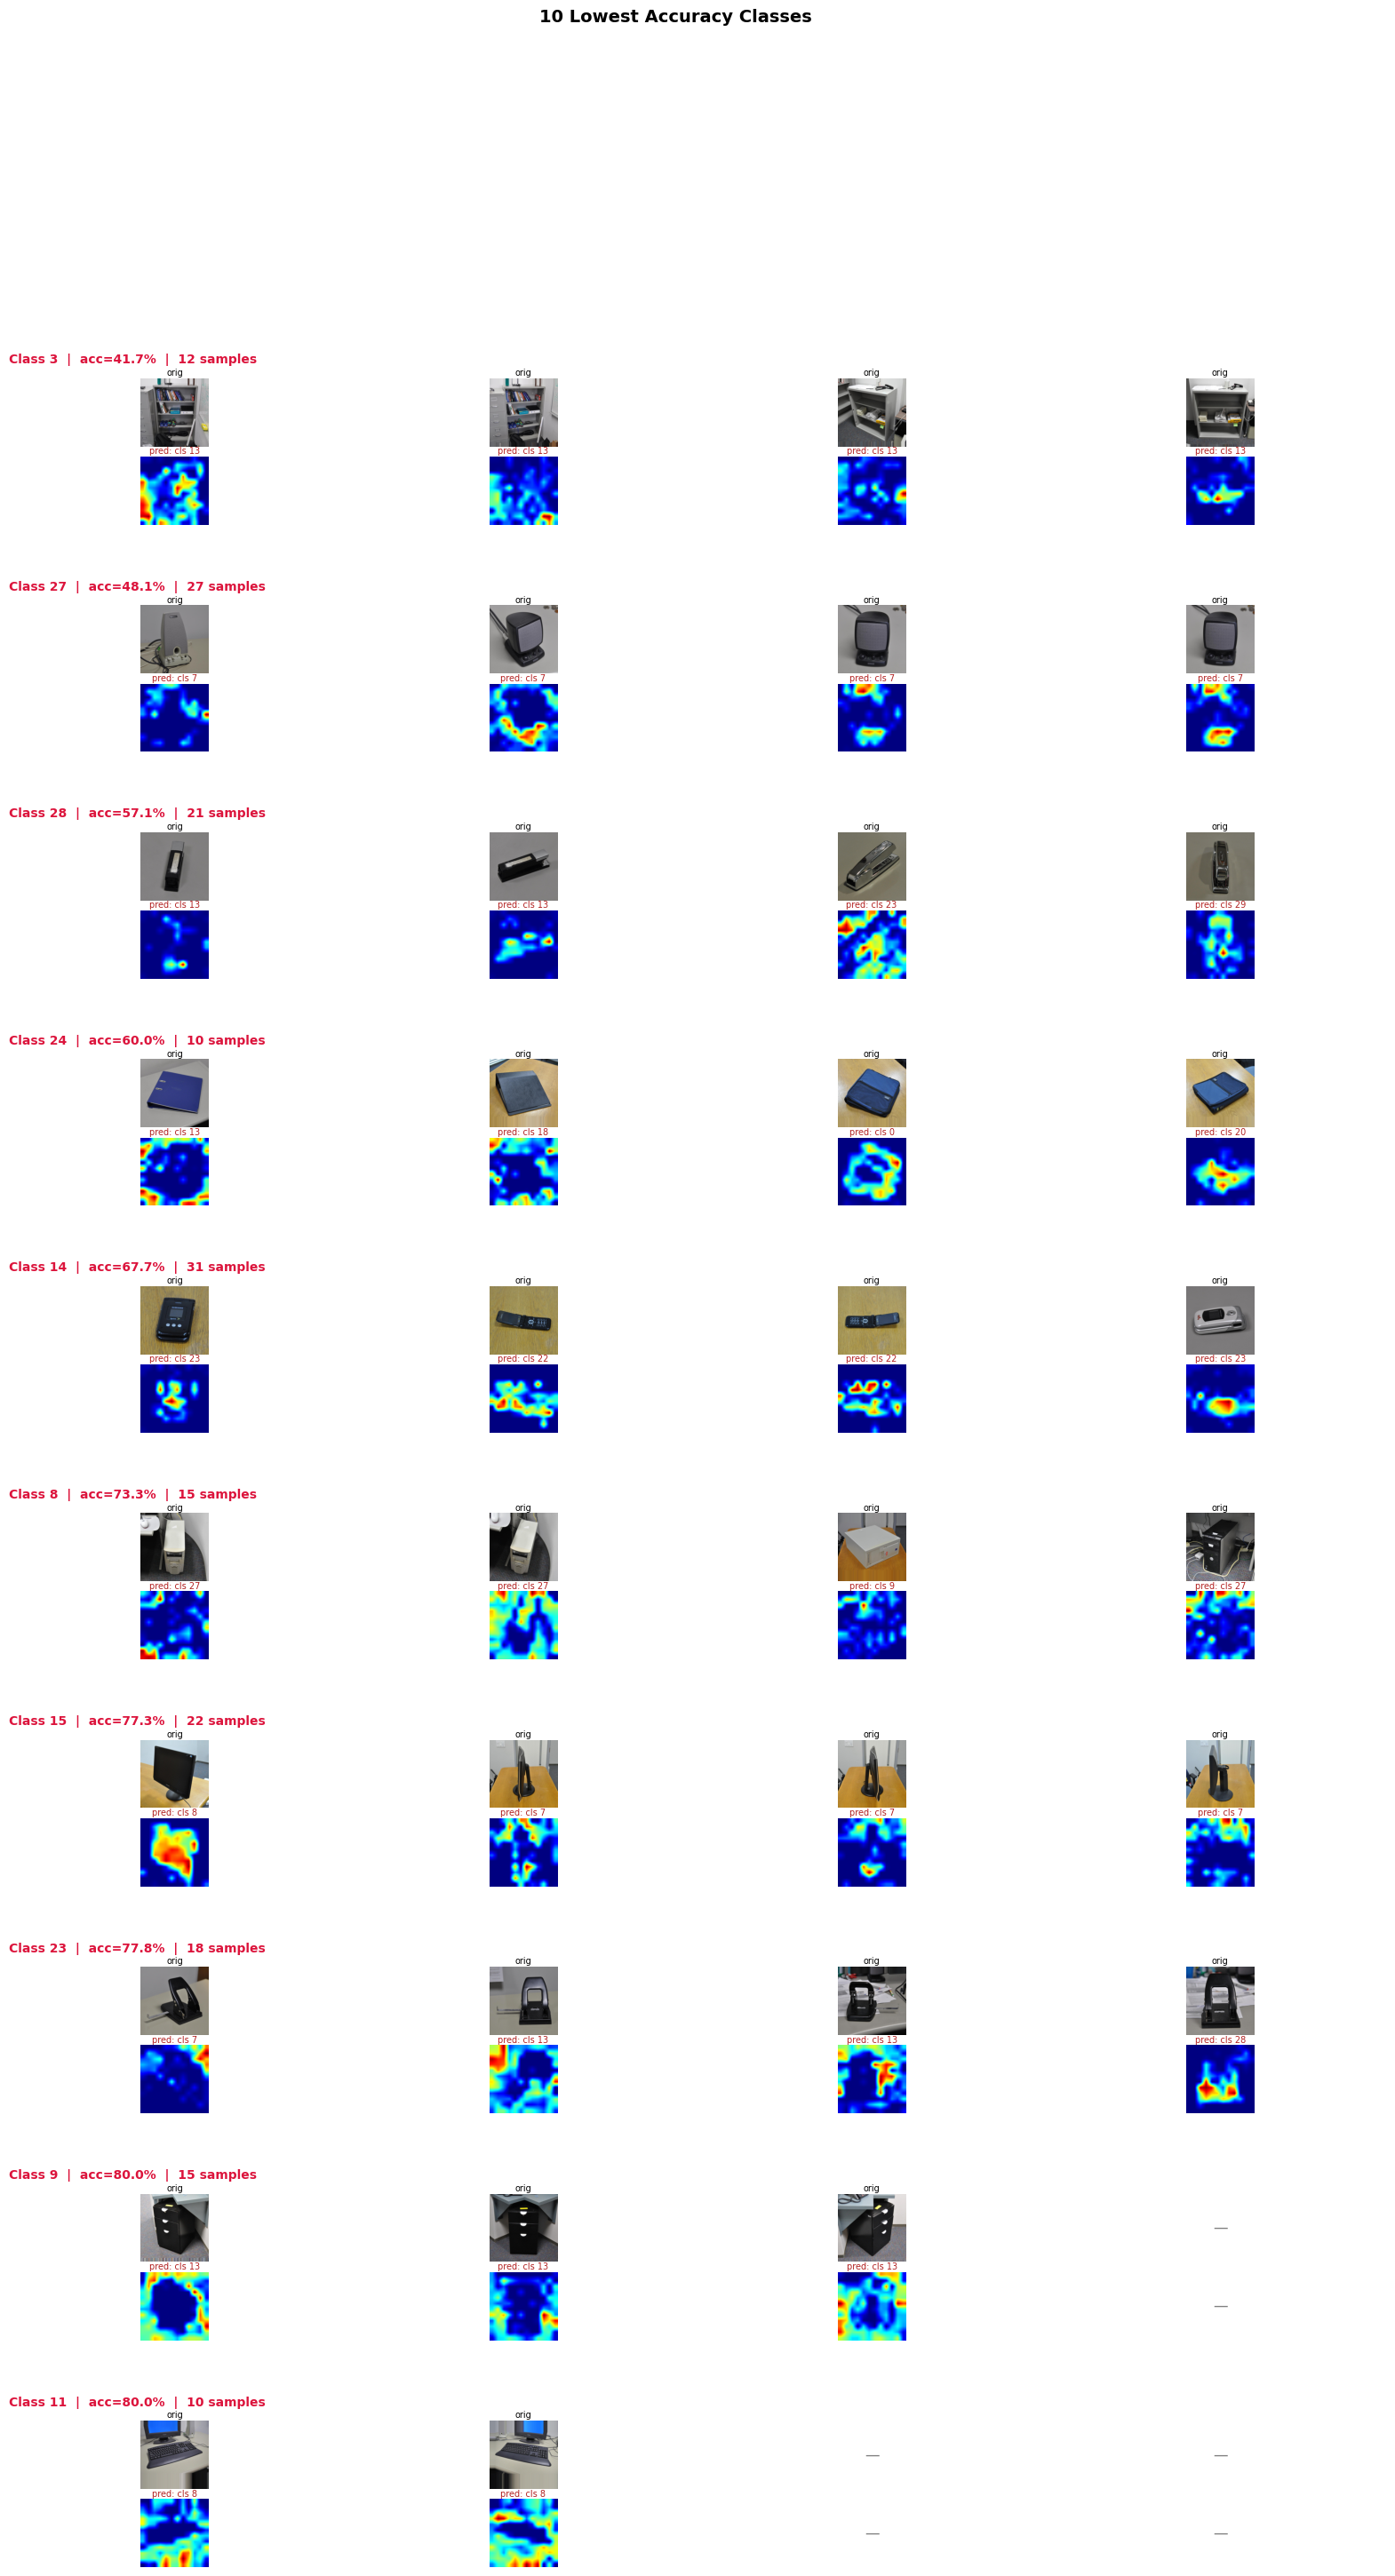

Saved → failures_grad.png


In [9]:
avg_loss, acc, class_acc = evaluate_and_visualize_failures(
    model=model,
    branch="src",
    test_loader=target_test_loader,
    device=device,
    num_classes=31,
    class_names=None,
    max_samples_per_class=4,
    save_path="failures_grad.png",
)

In [10]:
model_2 = Model(
    backbone_type="vit_b_32",
    in_dim=768,
    hidden_dim=256,
    out_dim=31,
    imgsize=384,
    attribute_layers=6,
    patch_size=32,
    attr_net_type="conv",
)
device = torch.device("cuda")
model_2 = model_2.to(device)
ckpt = torch.load("exp/exp_2/bi_best_100.00.pth", weights_only=False)
model_2.load_state_dict(ckpt["model_state_dict"])

Loaded pretrained weights.


<All keys matched successfully>

Overall — Loss: 0.5989 | Accuracy: 85.17%
  [24] Class 24: 20.0%  (2/10 correct)
  [28] Class 28: 52.4%  (11/21 correct)
  [5] Class 5: 66.7%  (8/12 correct)
  [23] Class 23: 66.7%  (12/18 correct)
  [29] Class 29: 68.2%  (15/22 correct)
  [11] Class 11: 70.0%  (7/10 correct)
  [14] Class 14: 71.0%  (22/31 correct)
  [27] Class 27: 74.1%  (20/27 correct)
  [3] Class 3: 75.0%  (9/12 correct)
  [4] Class 4: 81.2%  (13/16 correct)


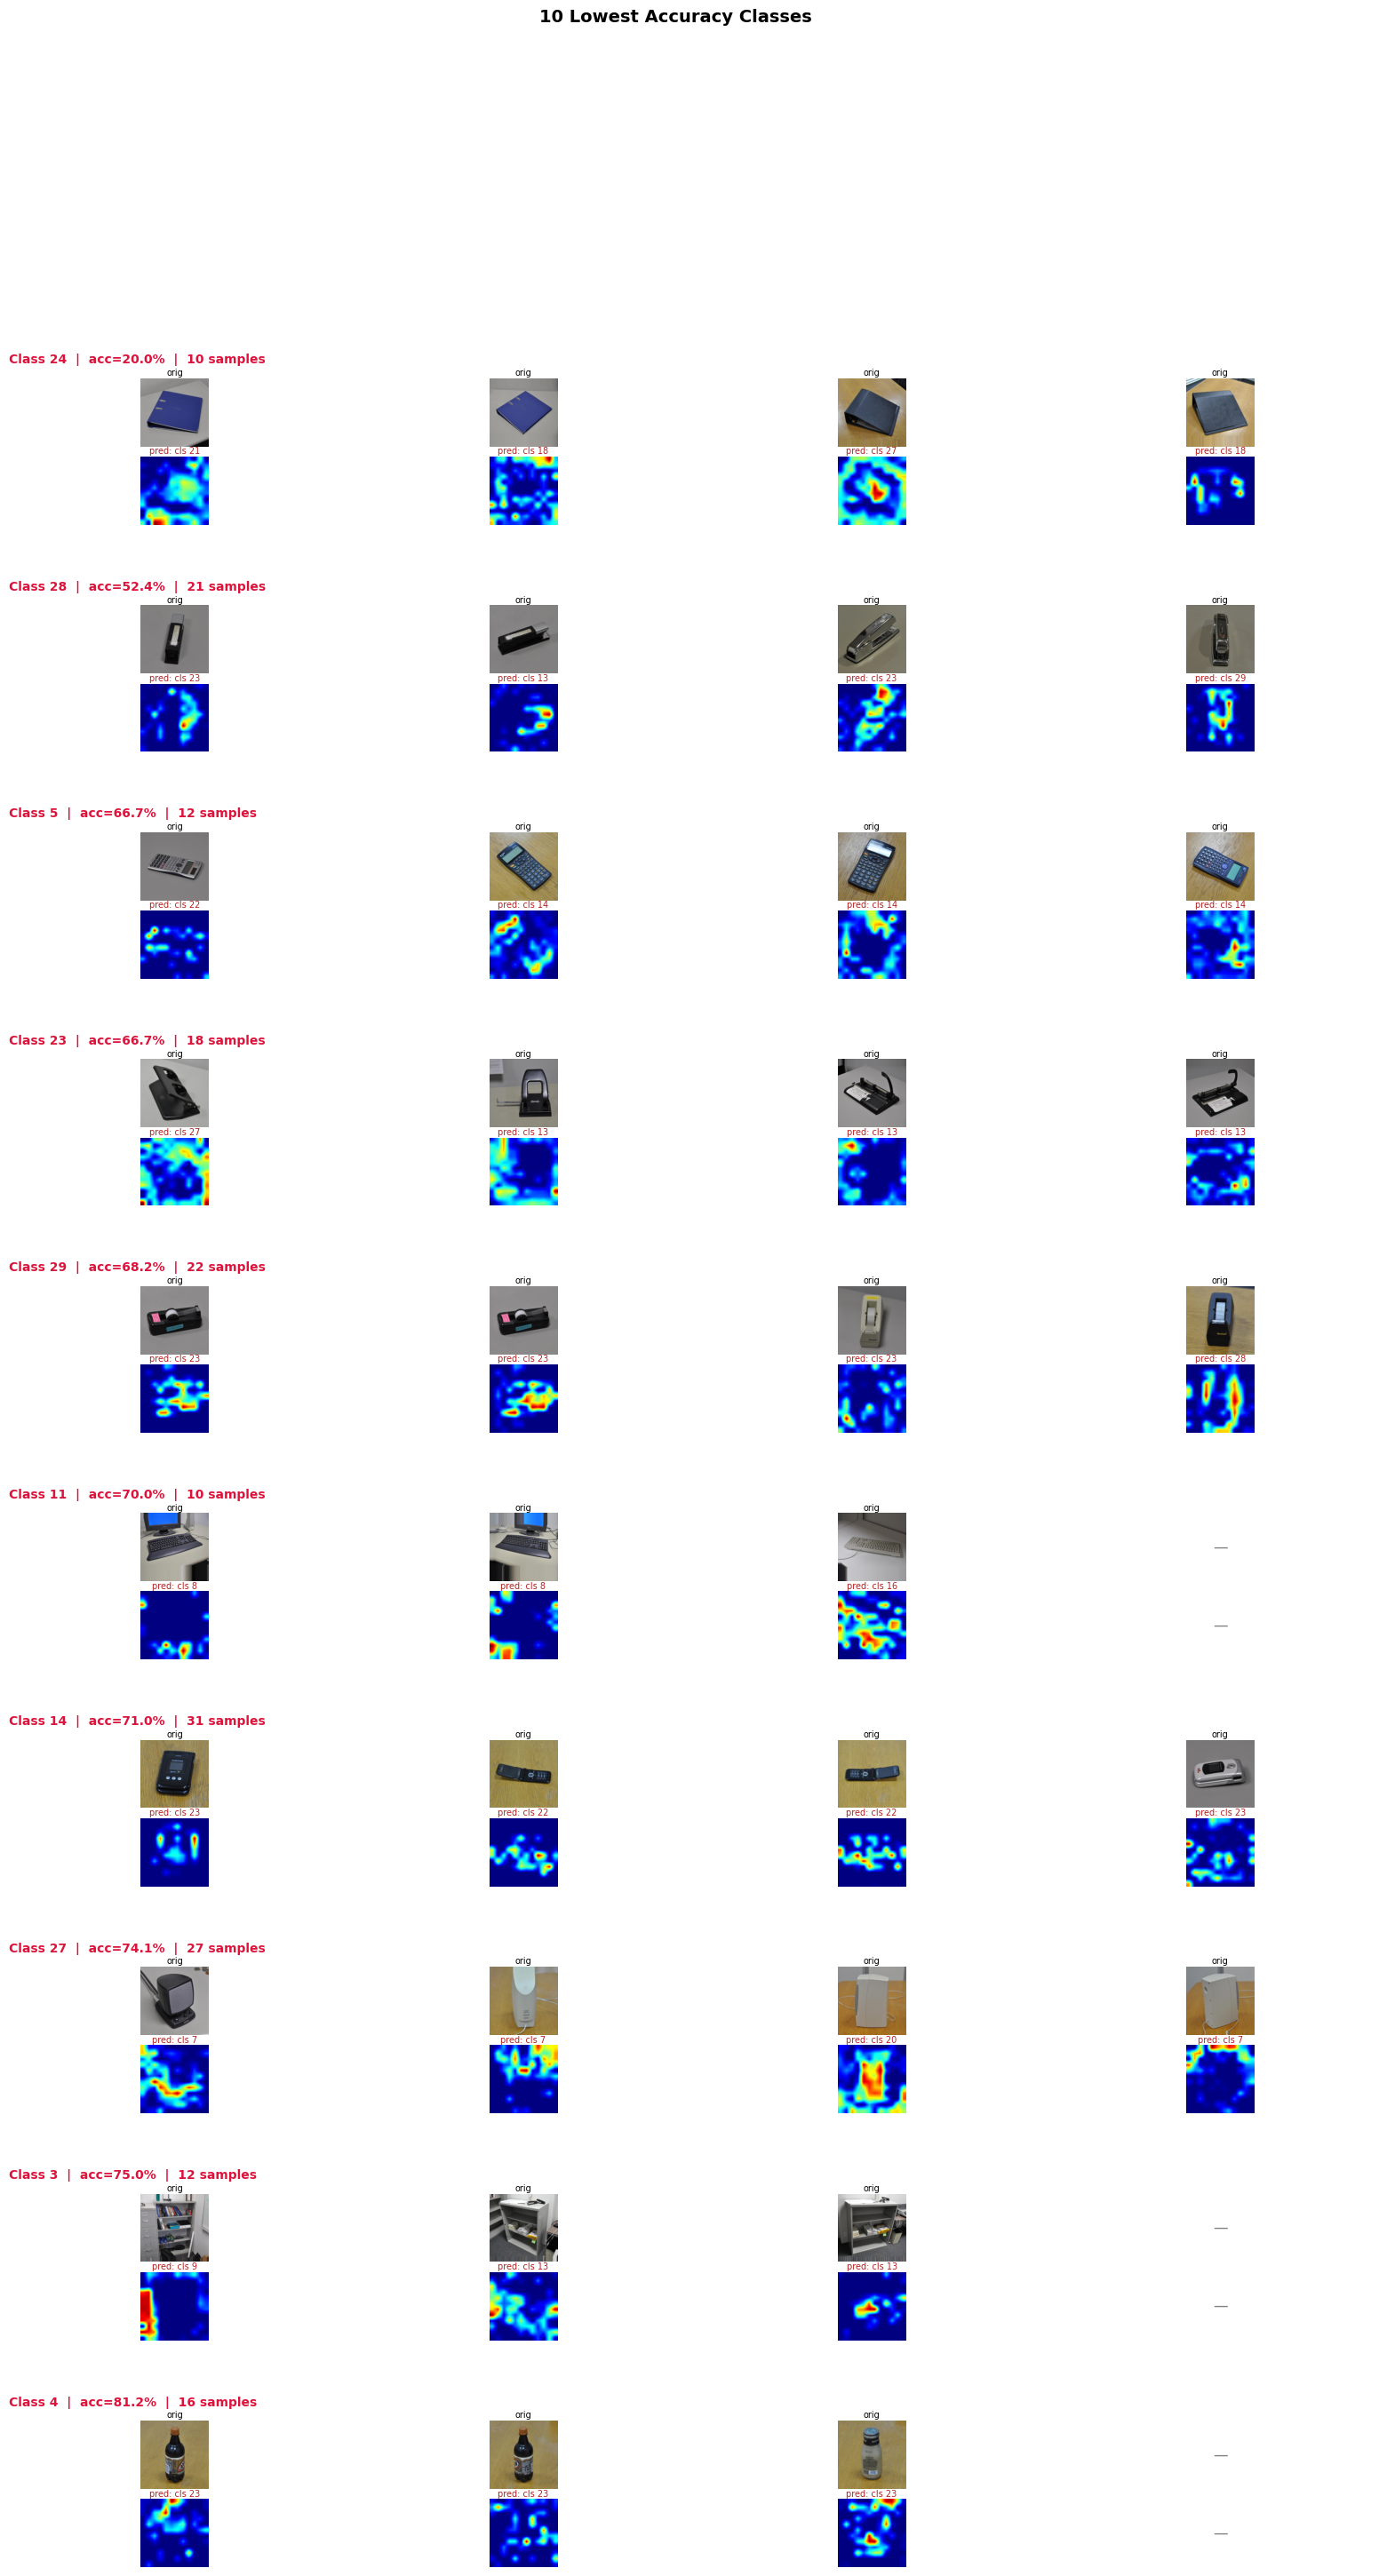

Saved → failures_grad_conv.png


In [11]:
avg_loss, acc, class_acc = evaluate_and_visualize_failures(
    model=model_2,
    branch="src",
    test_loader=target_test_loader,
    device=device,
    num_classes=31,
    class_names=None,
    max_samples_per_class=4,
    save_path="failures_grad_conv.png",
)